# Neck stretch 2D → 3D demo

Run a single still image of a left-neck lateral tilt through the project's pose stack:

1. Load image
2. RTMPose (via `Pose2D`) → 17 COCO-2D keypoints + skeleton overlay
3. MotionBERT-Lite (via `Pose3D`) → 17 H36M-3D keypoints, rendered as a rotatable matplotlib figure
4. `NeckStretchLeft.measure` → signed head-lateral-tilt angle in the body frontal plane
5. `analysis.rules_hold.score_frame` → in-target check + per-joint violations (this is what the live `HoldFSM` consumes every frame)
6. `ThaiCoachLLM.generate(HoldAnalysis, exercise=...)` → Thai summary text
7. Gemini TTS → speak the feedback

For the rotatable 3D plot, you need the `ipympl` widget backend:

```bash
uv add --dev jupyter ipympl
```

Then start the kernel with `uv run jupyter lab` and select this notebook.


In [1]:
import sys
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# Point this at your own left-neck-tilt image. PNG/JPG, head + torso fully visible.
IMAGE_PATH = PROJECT_ROOT / "data" / "neck_stretch" / "neck_stretch_01.jpg"
assert IMAGE_PATH.exists(), f"missing image: {IMAGE_PATH}"

## 1. Load and display the image


image: 500x500


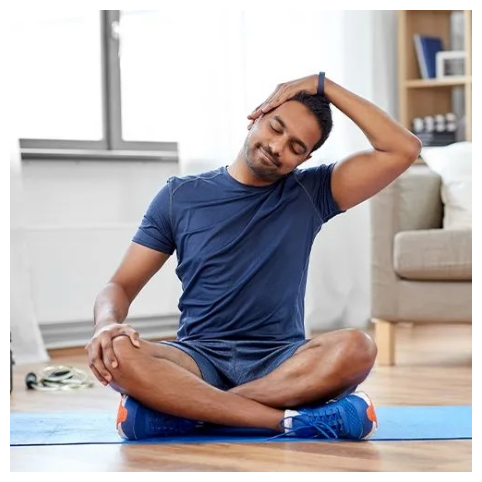

In [2]:
%matplotlib inline

frame_bgr = cv2.imread(str(IMAGE_PATH))
assert frame_bgr is not None, "cv2.imread returned None"
frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
H, W = frame_bgr.shape[:2]
print(f"image: {W}x{H}")

plt.figure(figsize=(8, 6))
plt.imshow(frame_rgb)
plt.axis("off")
plt.show()

## 2. 2D pose with RTMPose

Uses the project's `Pose2D` wrapper (YOLOX-tiny + RTMPose-s, ONNX/CPU). Returns 17 COCO-format keypoints + per-joint confidences.


In [3]:
from pose2d import Pose2D
from render import SKELETON  # COCO-17 bones

pose2d = Pose2D(device="cpu", mode="lightweight")
kps_2d, scores = pose2d.infer(frame_bgr)
print("kps:", kps_2d.shape, "scores:", scores.shape)
print("mean score:", float(scores.mean()))

load /Users/thatt/Dev/AI project/new-workout-ai/models/rtmlib_cache/hub/checkpoints/yolox_tiny_8xb8-300e_humanart-6f3252f9.onnx with onnxruntime backend
load /Users/thatt/Dev/AI project/new-workout-ai/models/rtmlib_cache/hub/checkpoints/rtmpose-s_simcc-body7_pt-body7_420e-256x192-acd4a1ef_20230504.onnx with onnxruntime backend
kps: (17, 2) scores: (17,)
mean score: 0.8676908016204834


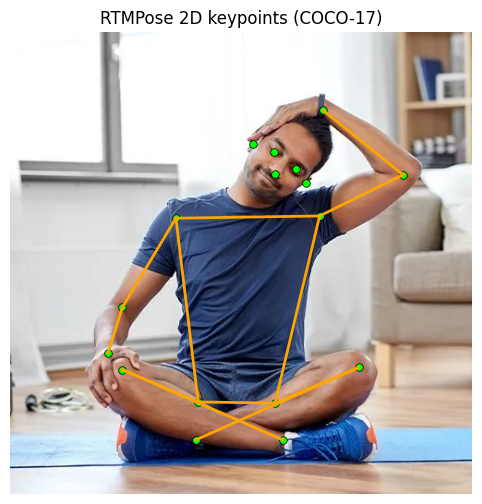

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(frame_rgb)

THRESH = 0.3
for a, b in SKELETON:
    if scores[a] < THRESH or scores[b] < THRESH:
        continue
    ax.plot(
        [kps_2d[a, 0], kps_2d[b, 0]],
        [kps_2d[a, 1], kps_2d[b, 1]],
        color="orange",
        linewidth=2,
    )

visible = scores >= THRESH
ax.scatter(
    kps_2d[visible, 0],
    kps_2d[visible, 1],
    s=30,
    c="lime",
    edgecolors="black",
    linewidths=0.5,
)
ax.set_title("RTMPose 2D keypoints (COCO-17)")
ax.axis("off")
plt.show()

## 3. Lift to 3D with MotionBERT-Lite

MotionBERT expects a temporal window of 27 frames in H36M-17 layout. For a still image we tile the same pose across the window — fine for a one-shot demo, though obviously the model can't infer any motion-dependent depth cues.


In [5]:
from pose3d import Pose3D, coco17_to_h36m17

pose3d = Pose3D()  # auto-selects MPS on Apple Silicon

h36m = coco17_to_h36m17(kps_2d, scores)  # (17, 3) [x, y, score]
window = np.stack([h36m] * pose3d.window_size, axis=0)  # (27, 17, 3)
kps_3d = pose3d.infer(window, frame_h=H, frame_w=W)  # (17, 3)
print("3D kps shape:", kps_3d.shape)
print("range x:", kps_3d[:, 0].min(), kps_3d[:, 0].max())
print("range y:", kps_3d[:, 1].min(), kps_3d[:, 1].max())
print("range z:", kps_3d[:, 2].min(), kps_3d[:, 2].max())

3D kps shape: (17, 3)
range x: -0.60238796 0.74941504
range y: -0.7778731 0.7488191
range z: -0.16182576 0.051815376


## 4. Rotatable 3D plot

Switches to the `ipympl` backend so the figure becomes a draggable widget. Click-and-drag to orbit, scroll to zoom.

Axis convention used here: MotionBERT emits coords with image-style y pointing down, so we flip it to render the person upright. Bones use the H36M-17 topology (different from the COCO skeleton used in 2D).


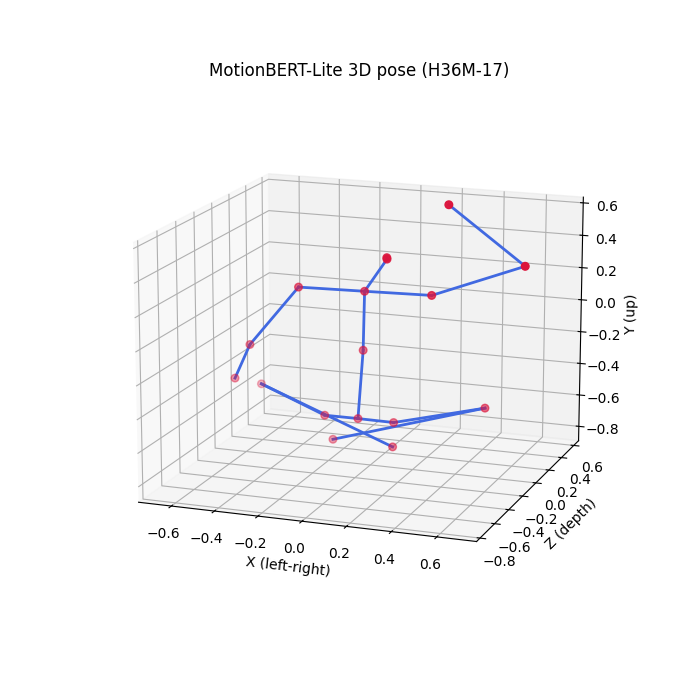

In [6]:
%matplotlib widget

# H36M-17 bones (pelvis-rooted).
H36M_SKELETON = [
    (0, 1),
    (1, 2),
    (2, 3),  # right leg
    (0, 4),
    (4, 5),
    (5, 6),  # left leg
    (0, 7),
    (7, 8),
    (8, 9),
    (9, 10),  # spine + head
    (8, 11),
    (11, 12),
    (12, 13),  # left arm
    (8, 14),
    (14, 15),
    (15, 16),  # right arm
]

X = kps_3d[:, 0]
Y = kps_3d[:, 2]  # depth → matplotlib Y
Z = -kps_3d[:, 1]  # flip image-down to up

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")

for a, b in H36M_SKELETON:
    ax.plot([X[a], X[b]], [Y[a], Y[b]], [Z[a], Z[b]], color="royalblue", linewidth=2)
ax.scatter(X, Y, Z, c="crimson", s=30)

# Equal-aspect cube so the figure isn't squashed.
max_range = np.array([np.ptp(X), np.ptp(Y), np.ptp(Z)]).max() / 2.0
mid = [X.mean(), Y.mean(), Z.mean()]
ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
ax.set_zlim(mid[2] - max_range, mid[2] + max_range)

ax.set_xlabel("X (left-right)")
ax.set_ylabel("Z (depth)")
ax.set_zlabel("Y (up)")
ax.view_init(elev=15, azim=-70)
ax.set_title("MotionBERT-Lite 3D pose (H36M-17)")
plt.show()

## 5. Head lateral tilt in the body frontal plane

Squat scoring leans on knee/hip/torso angles; the left-neck-stretch hold leans on a single signed measurement: the angle of the head vector (`thorax → head`) inside the body's own frontal plane. Sign convention from `body_frame_axes`: positive = head leans toward `body_lateral` (`L_hip → R_hip`, i.e. tilting **right**), negative = leans **left**. The target for `NeckStretchLeft` is **−35° ± 10°** (clear left-side tilt).

For context we also print the joint-angle table from the squat notebook — not because the hold scorer uses any of them, but as a sanity check that the 3D rig looks anatomically sensible.


In [7]:
from analysis.angles_3d import head_lateral_tilt_3d

tilt_deg = head_lateral_tilt_3d(kps_3d)
print(f"head_lateral_tilt: {tilt_deg:+.1f}°  (target for NeckStretchLeft: -35° ± 10°)")
if tilt_deg < 0:
    print("  → head is tilted to the LEFT in the body frame")
elif tilt_deg > 0:
    print("  → head is tilted to the RIGHT in the body frame")
else:
    print("  → head is upright")

# ---- generic per-joint sanity table (same format as the squat notebook) ----
H36M_NAMES = [
    "pelvis",
    "R_hip",
    "R_knee",
    "R_ankle",
    "L_hip",
    "L_knee",
    "L_ankle",
    "spine",
    "thorax",
    "neck",
    "head",
    "L_shoulder",
    "L_elbow",
    "L_wrist",
    "R_shoulder",
    "R_elbow",
    "R_wrist",
]

JOINT_TRIPLES = [
    (0, 1, 2),  # R hip
    (1, 2, 3),  # R knee
    (0, 4, 5),  # L hip
    (4, 5, 6),  # L knee
    (0, 7, 8),  # spine
    (7, 8, 9),  # thorax
    (8, 9, 10),  # neck (degenerate from single COCO nose kpt)
    (8, 11, 12),  # L shoulder
    (11, 12, 13),  # L elbow
    (8, 14, 15),  # R shoulder
    (14, 15, 16),  # R elbow
]


def joint_angle_deg(p, j, c, eps=1e-6):
    """Angle in degrees at joint `j` between bones j->p and j->c. nan if degenerate."""
    v1 = p - j
    v2 = c - j
    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)
    if n1 < eps or n2 < eps:
        return float("nan")
    cos = np.clip(np.dot(v1, v2) / (n1 * n2), -1.0, 1.0)
    return float(np.degrees(np.arccos(cos)))


print(f"\n{'joint':<12} {'angle (deg)':>12}")
print("-" * 26)
for p, j, c in JOINT_TRIPLES:
    ang = joint_angle_deg(kps_3d[p], kps_3d[j], kps_3d[c])
    print(f"{H36M_NAMES[j]:<12} {ang:>12.1f}")

head_lateral_tilt: -23.3°  (target for NeckStretchLeft: -35° ± 10°)
  → head is tilted to the LEFT in the body frame

joint         angle (deg)
--------------------------
R_hip               152.8
R_knee               13.0
L_hip               155.6
L_knee                7.2
spine               168.5
thorax              154.4
neck                147.8
L_shoulder          154.9
L_elbow              72.2
R_shoulder          121.3
R_elbow             166.3


## 6. Measure with the exercise + score the frame

Wrap the arrays we already have into a `PoseFrame`, instantiate `NeckStretchLeft`, and call `.measure(frame)` — this is the same call the live loop makes every frame. Then run `analysis.rules_hold.score_frame(target, measured)` to get the **in-target** boolean (consumed by `HoldFSM`) and the per-joint **violations** (consumed by the live LLM).


In [8]:
import time

from analysis.types import PoseFrame
from analysis.rules_hold import score_frame
from exercises.neck_stretch import NeckStretchLeft

frame = PoseFrame(
    timestamp=time.time(),
    keypoints_2d=kps_2d,
    scores=scores,
    frame_shape=(H, W),
    keypoints_3d=kps_3d,
)

exercise = NeckStretchLeft()
measured = exercise.measure(frame)
in_target, violations = score_frame(exercise.target, measured)

print(f"exercise: {exercise.name}  ({exercise.display_th})")
print(f"target.hold_seconds: {exercise.target.hold_seconds}")
for j in exercise.target.joints:
    m = measured[j.name]
    print(
        f"  {j.name}: measured {m:+.1f}°   target {j.target_deg:+.1f}° ± {j.tolerance_deg:.0f}°"
    )
print(f"\nin_target: {in_target}")
print(f"violations ({len(violations)}):")
for v in violations:
    print(f"  - {v.name} (sev {v.severity:.2f}): {v.detail_th}")

exercise: neck_stretch_left  (ยืดคอด้านซ้าย)
target.hold_seconds: 20.0
  head_lateral_tilt: measured -23.3°   target -35.0° ± 10°

in_target: False
violations (1):
  - head_lateral_tilt (sev 0.17): เอียงศีรษะไปทางซ้ายมากขึ้นอีกนิด


## 7. Thai coaching text from on-device LLM (Qwen3.5-4B mxfp4)

`ThaiCoachLLM.generate(payload, exercise=...)` dispatches on payload type. For a hold session the _real_ call is on `COMPLETE` with a `HoldAnalysis` produced by `analysis.rules_hold.score_hold(...)`. A single still has no temporal context, so we **stub** `in_target_ms` and `drift_count` here — picking values that simulate a clean 20 s hold so the score reflects only the posture, not a fake timer. The user prompt is still built by `feedback.prompt_th.build_hold_summary_prompt`.

The default `SYSTEM_TH_HOLD` in `feedback/prompt_th.py` allows 1-2 sentences and still drifts wordy. Below we override the system prompt with a **tighter coach voice** (2-3 short clauses, praise → fix, no preamble) and prime the model with **two few-shot examples** so the output matches the target style: `ทำได้ดีมาก ทำศีรษะให้นิ่งไว้ ศีรษะไม่เอียงไปทางซ้ายมากเกินไป`. The public `ThaiCoachLLM.generate` doesn't expose system-prompt or few-shot kwargs, so we bypass it and feed a custom `messages` list directly to `mlx_vlm.generate` — reusing the already-loaded model from `coach._model` / `coach._processor` / `coach._config` so we don't pay load + warmup twice.

We pass an explicit `model_dir` because `feedback/llm.py`'s default resolves one directory above the project root (a known wrinkle worth fixing later; for the demo we just pin the path). The **first** call after loading triggers MLX compilation and takes ~10–30 s on Apple Silicon — `warmup()` exists exactly so the cost is paid before the real generation.


In [9]:
import math
import re

from analysis.types import HoldAnalysis
from feedback.llm import ThaiCoachLLM
from feedback.prompt_th import build_hold_summary_prompt

QWEN_DIR = PROJECT_ROOT / "models" / "qwen3_5_4b_mxfp4"
assert QWEN_DIR.exists(), (
    f"missing Qwen weights: {QWEN_DIR} — run scripts/download_models.py"
)

# Stub a HoldAnalysis as if the user had held the target pose for the full 20 s,
# inheriting the violations the static frame actually exhibits. Mirrors how
# rules_hold.score_hold would build the payload at COMPLETE.
TARGET_MS = int(exercise.target.hold_seconds * 1000)
max_sev = {v.name: v.severity for v in violations}

duration_pts = 50  # stub: assume full hold
mean_sev = (
    sum(s for s in max_sev.values() if not math.isnan(s)) / max(len(max_sev), 1)
    if max_sev
    else 0.0
)
precision_pts = int(round(30 * (1.0 - min(1.0, mean_sev))))
stability_pts = 20  # stub: assume zero drifts
components = {
    "duration": duration_pts,
    "precision": precision_pts,
    "stability": stability_pts,
}
analysis = HoldAnalysis(
    exercise_name=exercise.name,
    score=sum(components.values()),
    components=components,
    violations=violations,
    in_target_ms=TARGET_MS,
    drift_count=0,
)
print(f"stub score: {analysis.score}/100   components: {analysis.components}")

# ---- Tighter coach voice: custom system prompt + few-shot priming ----
SYSTEM_TH_HOLD_CONCISE = (
    "คุณเป็นโค้ชยืดเหยียดที่พูดสั้น กระชับ เป็นภาษาไทย "
    "ตอบเป็นวลีสั้น ๆ 2-3 วลีในประโยคเดียว เริ่มด้วยคำชม แล้วบอกสิ่งที่ต้องปรับให้ชัดเจน "
    'เลียนสไตล์ตัวอย่างนี้: "ทำได้ดีมาก ทำศีรษะให้นิ่งไว้ ศีรษะไม่เอียงไปทางซ้ายมากเกินไป" '
    'ห้ามใช้ Markdown หัวข้อ หรือบุลเล็ต ห้ามใช้ภาษาอังกฤษ ห้ามตอบเกิน 3 วลี ห้ามขึ้นต้นด้วย "ผล" หรือคำนำใด ๆ'
)

FEW_SHOTS = [
    {
        "user": (
            "ผลการทำท่า ยืดคอด้านซ้าย: คะแนนรวม 95/100\n"
            "  ระยะเวลา: 50/50\n"
            "  ความแม่นยำ: 28/30\n"
            "  ความนิ่ง: 17/20\n"
            "ข้อสังเกต: (ไม่มี)\n"
            "ช่วยสรุปสั้น ๆ เป็นภาษาไทยว่าทำดีตรงไหน ควรปรับตรงไหน"
        ),
        "assistant": "ทำได้ดีมาก คอเอียงเข้าเป้าตลอด ทรงนิ่งสม่ำเสมอจนครบเวลา",
    },
    {
        "user": (
            "ผลการทำท่า ยืดคอด้านซ้าย: คะแนนรวม 68/100\n"
            "  ระยะเวลา: 35/50\n"
            "  ความแม่นยำ: 18/30\n"
            "  ความนิ่ง: 15/20\n"
            "ข้อสังเกต: เอียงศีรษะไปทางซ้ายมากขึ้นอีกนิด (ระดับ 0.60)\n"
            "ช่วยสรุปสั้น ๆ เป็นภาษาไทยว่าทำดีตรงไหน ควรปรับตรงไหน"
        ),
        "assistant": "ตั้งใจดี เอียงคอไปทางซ้ายให้มากขึ้นอีกนิด ทรงท่านิ่งจนครบเวลา",
    },
]


def generate_concise(
    coach: ThaiCoachLLM,
    analysis: HoldAnalysis,
    exercise,
    max_tokens: int = 96,
) -> str:
    """Bypass ThaiCoachLLM.generate so we can inject a custom system prompt + few-shot pairs.

    Reuses the model objects already loaded inside `coach`; doesn't load anything new.
    """
    from mlx_vlm import generate as mlx_generate
    from mlx_vlm.prompt_utils import apply_chat_template

    user = build_hold_summary_prompt(analysis, exercise)
    messages = [{"role": "system", "content": SYSTEM_TH_HOLD_CONCISE}]
    for ex in FEW_SHOTS:
        messages.append({"role": "user", "content": ex["user"]})
        messages.append({"role": "assistant", "content": ex["assistant"]})
    messages.append({"role": "user", "content": user})

    prompt = apply_chat_template(
        coach._processor, coach._config, messages, num_images=0, enable_thinking=False
    )
    result = mlx_generate(
        coach._model,
        coach._processor,
        prompt=prompt,
        max_tokens=max_tokens,
        verbose=False,
    )
    text = getattr(result, "text", str(result))
    return re.sub(r"<think>.*?</think>\s*", "", text, flags=re.DOTALL).strip()


t0 = time.time()
coach = ThaiCoachLLM(model_dir=QWEN_DIR)
print(f"loaded in {time.time() - t0:.1f}s")

t0 = time.time()
coach.warmup()
print(f"warmup in {time.time() - t0:.1f}s")

t0 = time.time()
coach_text = generate_concise(coach, analysis, exercise)
print(f"generated in {time.time() - t0:.1f}s\n")
print(coach_text)

stub score: 95/100   components: {'duration': 50, 'precision': 25, 'stability': 20}
loaded in 2.1s
warmup in 0.2s
generated in 0.2s

ทำได้ดีมาก ทรงตัวนิ่งจนครบเวลา ปรับศีรษะให้เอียงไปทางซ้ายมากขึ้นอีกนิด


## 8. Speak the feedback — Gemini TTS

Same call pattern as `scripts/test_sound.py`: Gemini 2.5 Flash TTS with the `Charon` prebuilt voice, 24 kHz mono PCM written into a WAV container. Reads the API key from `.env` under the (lowercase) name `google_ai_studio_api_key`, matching the existing script.


In [10]:
import os
import wave

from dotenv import load_dotenv
from google import genai
from google.genai import types

load_dotenv(PROJECT_ROOT / ".env")
tts_client = genai.Client(api_key=os.environ["google_ai_studio_api_key"])

# Speak only the concise coach line — no preamble. The TTS output should match
# the LLM output 1:1 so the audio is as short and direct as the on-screen text.
tts_script = coach_text
print(f"--- tts_script ({len(tts_script)} chars) ---")
print(repr(tts_script))

t0 = time.time()
tts_response = tts_client.models.generate_content(
    model="gemini-2.5-flash-preview-tts",
    contents=tts_script,
    config=types.GenerateContentConfig(
        response_modalities=["AUDIO"],
        speech_config=types.SpeechConfig(
            voice_config=types.VoiceConfig(
                prebuilt_voice_config=types.PrebuiltVoiceConfig(voice_name="Charon")
            )
        ),
    ),
)
print(f"\nTTS call returned in {time.time() - t0:.1f}s")

# --- Defensive unpacking with diagnostics ---
print("prompt_feedback:", getattr(tts_response, "prompt_feedback", None))
if not tts_response.candidates:
    raise RuntimeError("TTS returned no candidates")

cand = tts_response.candidates[0]
print("finish_reason:", getattr(cand, "finish_reason", None))
print("safety_ratings:", getattr(cand, "safety_ratings", None))

if cand.content is None or not getattr(cand.content, "parts", None):
    raise RuntimeError(
        f"TTS produced no audio content. finish_reason={getattr(cand, 'finish_reason', None)}. "
        f"See prints above for the input that was sent."
    )

part = cand.content.parts[0]
if part.inline_data is None:
    raise RuntimeError(f"TTS part has no inline_data. Part: {part}")

pcm = part.inline_data.data
wav_path = PROJECT_ROOT / "notebooks" / "data" / "neck_stretch_coach.wav"
wav_path.parent.mkdir(parents=True, exist_ok=True)
with wave.open(str(wav_path), "wb") as wf:
    wf.setnchannels(1)
    wf.setsampwidth(2)
    wf.setframerate(24000)
    wf.writeframes(pcm)
print(f"\nwrote {len(pcm)} bytes of PCM → {wav_path}")

--- tts_script (70 chars) ---
'ทำได้ดีมาก ทรงตัวนิ่งจนครบเวลา ปรับศีรษะให้เอียงไปทางซ้ายมากขึ้นอีกนิด'

TTS call returned in 5.0s
prompt_feedback: None
finish_reason: FinishReason.STOP
safety_ratings: None

wrote 273166 bytes of PCM → /Users/thatt/Dev/AI project/new-workout-ai/notebooks/data/neck_stretch_coach.wav


## 9. Play the result inline


In [11]:
from IPython.display import Audio

Audio(str(wav_path), autoplay=False)